## Set up

In [7]:
# ============================================================
# BACKTEST: Run SEPAHybridV1 from Notebook
# ============================================================
# Paste this into a notebook cell. It will:
# 1. Score the universe from T3 (daily, ~125K rows)
# 2. Run the full BackTrader backtest
# 3. Display QuantStats interactive tearsheet inline
# 4. Show trade log and summary stats
import sys, logging
from pathlib import Path
from datetime import datetime, timedelta
import quantstats as qs
import pandas as pd
import importlib
%load_ext autoreload
%autoreload 2

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

MODEL = 'm01_prototype_2003_2026' # 22 24
VERSION = "v1"
model_dir = ROOT / 'models' / MODEL / VERSION
model_path  = str(model_dir / 'model.json')
cal_path  = model_dir / 'calibration.json'
cal_str   = str(cal_path) if cal_path.exists() else None

logging.basicConfig(level=logging.WARNING,
                    format='%(asctime)s | %(levelname)s | %(message)s',
                    datefmt='%H:%M:%S')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from src.backtest.universe_scorer import UniverseScorer
scorer = UniverseScorer(m01_path=model_path)
scores_df = scorer.score_from_t3('2019-01-01', '2026-04-30')

18:26:09 | WARNING | No calibration table at models\m01_calibration.json


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
scores_df.to_parquet('scores_cache.parquet')

In [10]:
# ============================================================
# BACKTEST HELPER
# ============================================================
def reload_backtest():
    """Reload all backtest modules (call after editing source)."""
    import src.backtest.runner, src.backtest.sepa_strategy, src.backtest.universe_scorer
    importlib.reload(src.backtest.universe_scorer)
    importlib.reload(src.backtest.runner)
    importlib.reload(src.backtest.sepa_strategy)

reload_backtest()
from src.backtest.runner import SEPABacktestRunner
from src.backtest.sepa_strategy import SEPAHybridV1, SEPAFlatV1
from src.backtest.universe_scorer import UniverseScorer

def run_backtest(
    start: str,
    end: str,
    strategy=SEPAFlatV1,
    model: str = 'models/m01_prototype/model.json',
    cash: float = 100_000,
    warmup_months: int = 6,
    max_tickers: int = None,
    scores_df: pd.DataFrame = None,   # ← pass pre-scored df to skip scoring
    **strategy_overrides,
):
    eval_start = start
    bt_start = (datetime.strptime(start, '%Y-%m-%d') - timedelta(days=warmup_months * 30)).strftime('%Y-%m-%d')
    score_start = (datetime.strptime(bt_start, '%Y-%m-%d') - timedelta(days=365)).strftime('%Y-%m-%d')
    
    # 1. Score (skip if pre-scored df provided)
    if scores_df is None:
        print(f"[1/3] Scoring ({score_start} → {end})...")
        scorer = UniverseScorer(m01_path=model)
        scores_df = scorer.score_from_t3(score_start, end)
        print(f"      {len(scores_df):,} rows, {scores_df['ticker'].nunique()} tickers")
    else:
        print(f"[1/3] Using pre-scored df ({len(scores_df):,} rows, {scores_df['ticker'].nunique()} tickers)")
    
    # 2. Setup
    print(f"[2/3] Setting up ({bt_start} → {end}, eval from {eval_start})...")
    runner = SEPABacktestRunner(start_date=bt_start, end_date=end, initial_cash=cash)
    runner.setup(scores_df=scores_df, max_tickers=max_tickers)
    
    runner.cerebro.strats = []
    runner.cerebro.addstrategy(strategy, scores_df=scores_df, **strategy_overrides)
    
    # 3. Run
    print(f"[3/3] Running backtest...")
    metrics = runner.run()
    runner.print_results(metrics)
    
    # 4. Trade analysis (eval window only)
    trade_df = runner.get_trade_dataframe()
    if trade_df is not None and len(trade_df) > 0:
        trade_df['entry_date'] = pd.to_datetime(trade_df['entry_date'])
        eval_trades = trade_df[trade_df['entry_date'] >= eval_start]
        
        if len(eval_trades) > 0:
            wins = eval_trades[eval_trades['pnl_percent'] > 0]
            losses = eval_trades[eval_trades['pnl_percent'] <= 0]
            pf = abs(wins['pnl_percent'].sum() / losses['pnl_percent'].sum()) if len(losses) and losses['pnl_percent'].sum() != 0 else float('inf')
            
            print(f"\n{'='*50}")
            print(f"EVAL WINDOW: {eval_start} → {end}")
            print(f"{'='*50}")
            print(f"  Trades:         {len(eval_trades)}")
            print(f"  Win Rate:       {len(wins)/len(eval_trades)*100:.1f}%")
            print(f"  Avg PnL:        {eval_trades['pnl_percent'].mean():+.2f}%")
            print(f"  Median PnL:     {eval_trades['pnl_percent'].median():+.2f}%")
            print(f"  Profit Factor:  {pf:.2f}")  

    return metrics, runner, trade_df


## Enrichment & Data Prep

## Run Backtest

In [11]:
SWEEP_BEST = {
    'min_prob_elite': 0.5, 
    'stop_loss_pct': 0.2,  
    'sma_exit_period': 100,
}
strategy_kwargs = {
 # Overrides from the vectorized sweep
    'min_prob_elite': SWEEP_BEST['min_prob_elite'],
    'max_stop_pct': SWEEP_BEST['stop_loss_pct'],
    'sma_exit_period': SWEEP_BEST['sma_exit_period'],
    
    # Static parameters you want to enforce
    'min_score': 30,               
    'rank_by': 'trailing',
    'min_price': 5.0,
    'cooldown_days': 3,
    'warmup_days': 10,
    'atr_stop_mult': 2.0,                           
    'atr_target1_mult': 3.0,       
    'min_target1_pct': 0.15,
    'atr_target2_add': 2.0,
    
    # Use Hybrid mode's regime sizing
    'sizing_mode': 'equal_weight',
    'regime_max_pos': {0:0, 1:10, 2:10, 3:10, 4:10},
    # 'regime_sizes': {0:0.0, 1:0.1, 2:0.1, 3:0.1, 4:0.10},
}

# 3. Add the strategy to cerebro
# runner.cerebro.addstrategy(SEPAHybridV1, **strategy_kwargs)

metrics, runner, trades = run_backtest(
    '2025-01-01', 
    '2025-12-31', 
    strategy=SEPAHybridV1, 
    model=model_path, 
    **strategy_kwargs, 
    scores_df = scores_df
)



[1/3] Using pre-scored df (4,029,491 rows, 2687 tickers)
[2/3] Setting up (2024-07-05 → 2025-12-31, eval from 2025-01-01)...
[3/3] Running backtest...


18:43:27 | WARNING | Order failed for ATEC: 7
18:43:28 | WARNING | Order failed for PLTR: 7
18:43:29 | WARNING | Order failed for ACMR: 7
18:43:29 | WARNING | Order failed for ALDX: 7
18:43:30 | WARNING | Order failed for PTGX: 7
18:43:31 | WARNING | Order failed for OMER: 7
18:43:33 | WARNING | Order failed for LTBR: 7
18:43:36 | WARNING | Order failed for TNGX: 7
18:43:38 | WARNING | Order failed for AMPX: 7
18:43:44 | WARNING | Order failed for URGN: 7
18:43:44 | WARNING | Order failed for ANRO: 7



SEPA HYBRID V1 BACKTEST RESULTS

Period: 2024-07-05 to 2025-12-31
Starting Capital: $100,000

--- PERFORMANCE ---
Final Value:     $95,576.78
Total Return:    -4.42%
Sharpe Ratio:    0.03786203900645459
SQN:             0.05269113210706304

--- RISK ---
Max Drawdown:    35.89%
Max DD Length:   169 bars

--- TRADES ---
Total Trades:    155
Win Rate:        39.4%
Won/Lost:        61/84
Net Profit:      $1,354.66

--- EXPOSURE ---
Avg Exposure:    84.1%
Max Exposure:    99.8%
Time Invested:   95.3%
Avg Positions:   8.9

--- SIGNAL REJECTIONS ---
Total Rejected:  27,760
  - no_slots: 22,172
  - low_price: 2,305
  - already_holding: 1,833


EVAL WINDOW: 2025-01-01 → 2025-12-31
  Trades:         145
  Win Rate:       41.4%
  Avg PnL:        +1.01%
  Median PnL:     -7.17%
  Profit Factor:  1.10



QUANTSTATS TEARSHEET
CAGR:           -4.34%
Sharpe:         0.08
Sortino:        0.12
Max Drawdown:   -35.89%
Calmar:         -0.12
Win Rate:       55.5%



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2025-01-22   2025-01-22
End Period                 2025-12-31   2025-12-31
Risk-Free Rate             0.0%         0.0%
Time in Market             97.0%        97.0%

Cumulative Return          14.41%       -4.42%
CAGR﹪                     14.78%       -4.53%

Sharpe                     0.81         0.09
Prob. Sharpe Ratio         79.48%       53.4%
Smart Sharpe               0.72         0.08
Sortino                    1.22         0.12
Smart Sortino              1.09         0.11
Sortino/√2                 0.86         0.08
Smart Sortino/√2           0.77         0.07
Omega                      1.19         1.01

Max Drawdown               -18.76%      -35.89%
Max DD Date                2025-04-08   2025

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2025-01-24,2025-04-08,2025-09-17,237,-35.894872,-32.131696
2,2025-10-16,2025-11-13,2025-12-31,77,-17.650437,-16.695432
3,2025-09-23,2025-09-26,2025-09-30,8,-3.554249,-2.936026
4,2025-10-10,2025-10-10,2025-10-10,1,-3.359609,NaN
5,2025-10-06,2025-10-07,2025-10-08,3,-2.370000,-0.716416


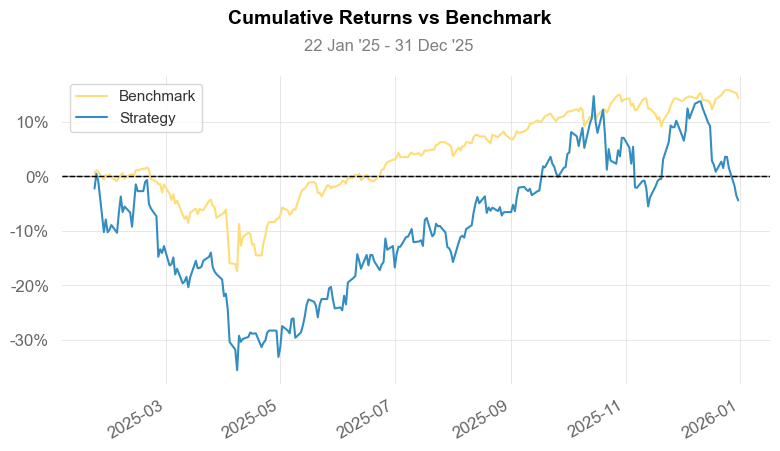

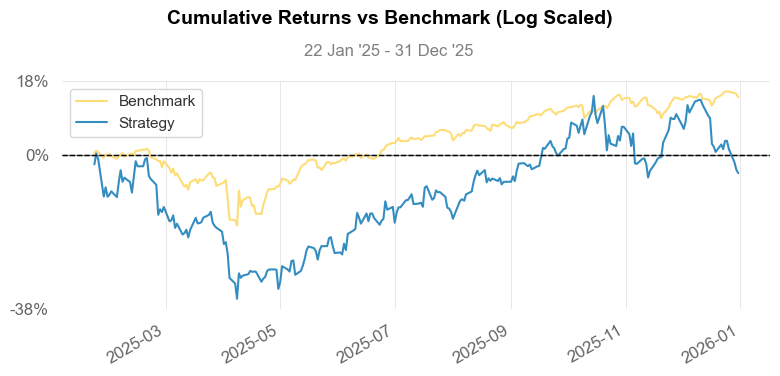

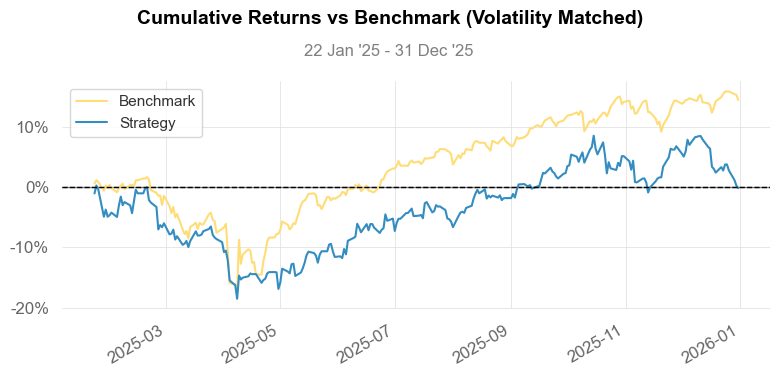

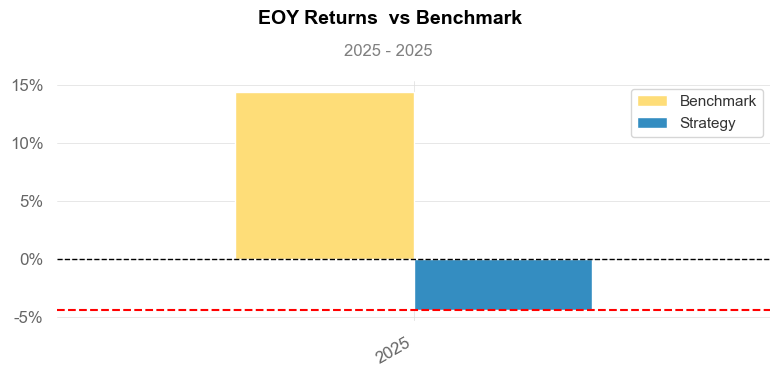

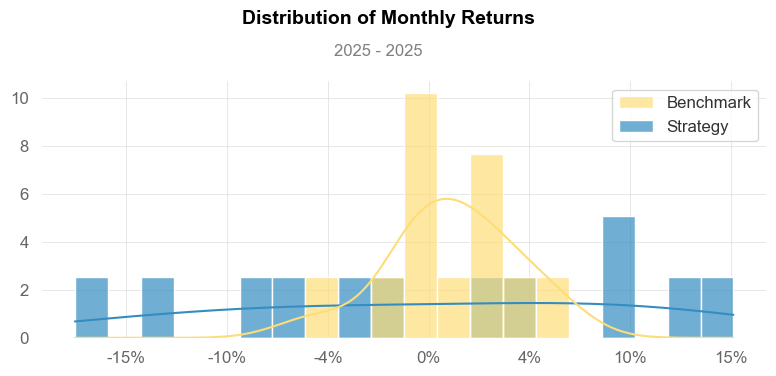

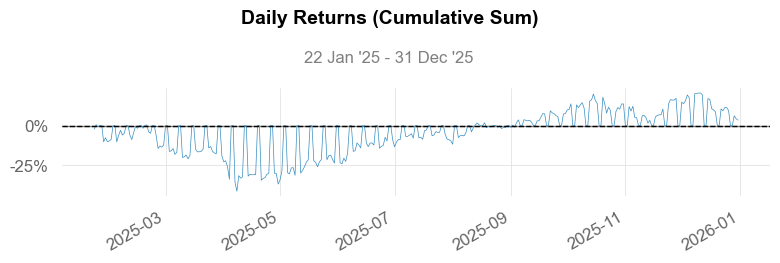

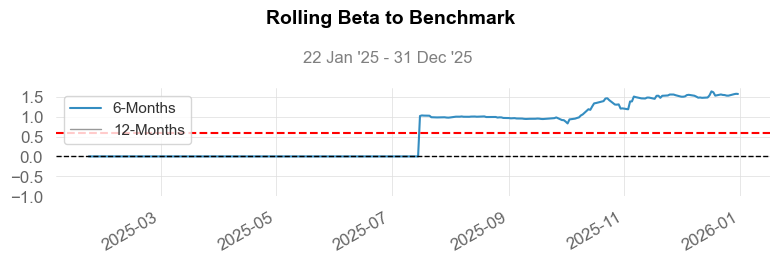

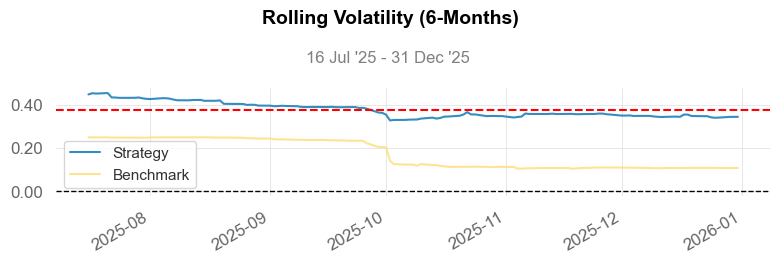

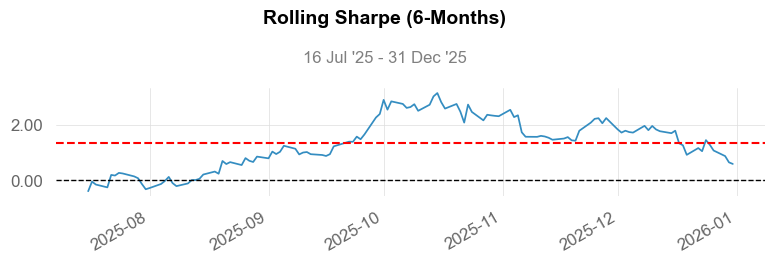

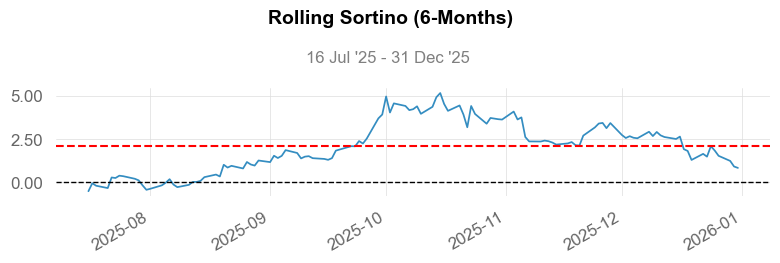

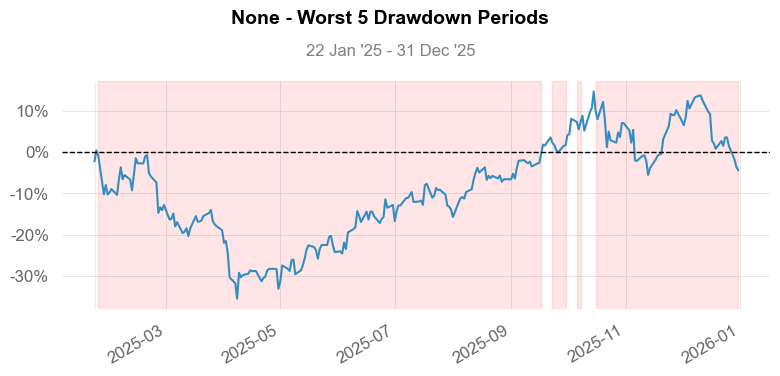

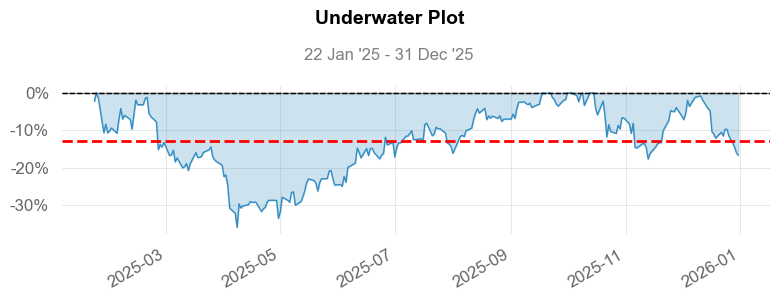

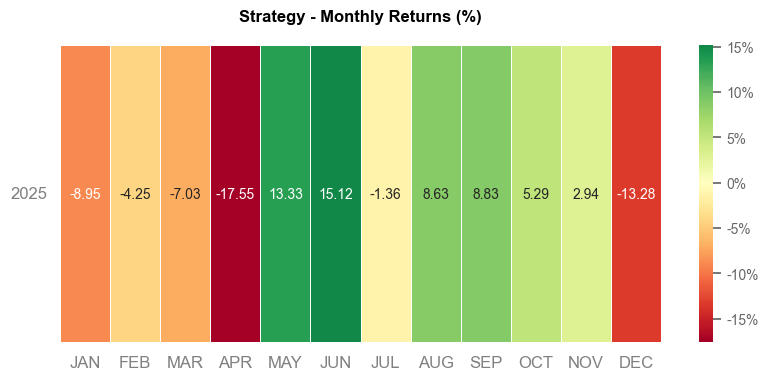

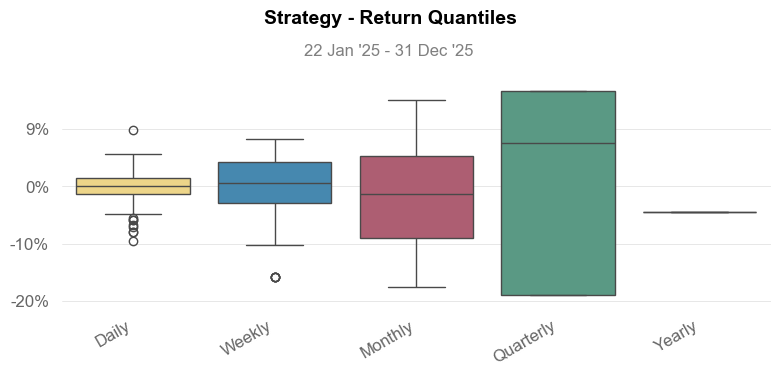

In [14]:
# QuantStats tearsheet after any run

equity_df = runner.get_equity_curve_dataframe()
if equity_df is not None and len(equity_df) > 2:
    returns = equity_df['value'].pct_change().dropna()
    returns.index = pd.to_datetime(returns.index)
    returns.index.name = None  # QuantStats requirement
    print(f"\n{'='*60}")
    print("QUANTSTATS TEARSHEET")
    print(f"{'='*60}")
    qs.extend_pandas()
    # Show key metrics inline
    print(f"CAGR:           {qs.stats.cagr(returns)*100:.2f}%")
    print(f"Sharpe:         {qs.stats.sharpe(returns):.2f}")
    print(f"Sortino:        {qs.stats.sortino(returns):.2f}")
    print(f"Max Drawdown:   {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Calmar:         {qs.stats.calmar(returns):.2f}")
    print(f"Win Rate:       {qs.stats.win_rate(returns)*100:.1f}%")
    
    # Full interactive HTML tearsheet (renders in notebook)
    qs.reports.full(returns, benchmark='SPY', output=None, download_filename=None)

In [15]:
trades_df = runner.get_trade_dataframe()
trades_df.head()

,ticker,entry_date,entry_price,exit_date,exit_price,exit_reason,entry_regime,entry_score,initial_size,pnl_percent,...,rs_vs_sector,rs_vs_industry,sector_momentum,industry_momentum,rs_universe_rank,calibrated_score,prob_elite,daily_pct_rank,trailing_pct,normalized_score
0,VERU,2025-01-21,10.91090,2025-01-28,6.59340,stop,4,78.742976,917,-39.570520,...,-1.077273,-0.859707,0.412329,0.358035,0.470121,28.917302,0.562270,0.998743,0.997570,78.742976
1,AISP,2025-01-21,6.00000,2025-01-28,4.85514,stop,4,77.546558,1721,-19.080998,...,-1.513897,-1.453823,0.574815,0.544099,0.631007,28.547678,0.587709,0.997485,0.996397,77.546558
2,MXL,2025-01-21,25.04502,2025-01-28,19.57041,stop,4,77.420546,401,-21.859076,...,-0.656192,-0.207553,0.574815,0.452282,0.852904,28.508747,0.563517,0.996647,0.996062,77.420546
3,NEXT,2025-01-21,8.84884,2025-01-29,7.79400,stop,4,79.657025,1104,-11.920658,...,0.390165,0.450861,0.488380,0.483970,0.925616,29.199691,0.593655,0.999581,0.998198,79.657025
4,CRMD,2025-01-28,12.14213,2025-02-03,9.91008,stop,3,79.861491,757,-18.382689,...,1.972613,2.028180,0.436123,0.371707,0.978535,29.262859,0.620339,0.999154,0.998321,79.861491


In [16]:
# 2. Time series of price & score changes for EVERY day during holding
daily_df = runner.get_daily_holding_dataframe()
display(daily_df.head())

,ticker,entry_date,date,days_held,close,pct_change_from_entry,m01_score,trailing_pct
0,VERU,2025-01-21,2025-01-21,0,10.9,-0.099900,78.742976,0.997570
1,VERU,2025-01-21,2025-01-22,1,10.4,-4.682474,73.396380,0.989148
2,VERU,2025-01-21,2025-01-23,2,12.8,17.313885,81.066781,0.999204
3,VERU,2025-01-21,2025-01-24,3,12.1,10.898283,76.975406,0.995685
4,VERU,2025-01-21,2025-01-27,4,6.4,-41.343058,67.210627,0.965743


## (Optional) Parameter Sweep

In [17]:
import itertools
import time
import pandas as pd
import quantstats as qs
import duckdb
from src.backtest.vectorized_backtest import VectorizedSEPABacktest
from src.backtest.universe_scorer import UniverseScorer

GRID = {
    'min_prob_elite':        [0.1, 0.5, 0.8],
    'stop_loss_pct':         [0.10, 0.15, 0.2, 0.25],
    'sma_exit_period':       [20, 100],
    'max_positions_per_day': [3, 8, 10],
}

FIXED = dict(
    model_path=model_path,
    start_date='2020-01-01',
    end_date='2025-01-01',
    ranking_lookback_days=10,
    warmup_days=10,
    initial_cash=100_000,
    position_size_pct=0.10,
    max_hold_days=252,
)

In [18]:
# ── Pre-compute ONCE (scores + raw prices) ────────────────────────────
t0 = time.time()

# scorer = UniverseScorer(m01_path=model_path, calibration_path=None)
# Sweep (fast — no trailing_pct):
# scores_cache = scorer.score_from_t3(start, end, ranking_lookback_days=10)
scores_cache = scores_df
# Dashboard / analysis (full output):
# scores_full = scorer.score_from_t3(start, end, ranking_lookback_days=10, compute_trailing_pct=True)

# Load all prices for every ticker that ever appears in scores
all_tickers = scores_cache['ticker'].unique().tolist()
con = duckdb.connect(str(__import__('config').DATA_DIR / 'market_data.duckdb'), read_only=True)
prices_cache = con.execute("""
    SELECT ticker, date, open, high, low, close
    FROM price_data
    WHERE ticker = ANY(?) AND date >= ? AND date <= ?
    ORDER BY ticker, date
""", [all_tickers, FIXED['start_date'], FIXED['end_date']]).fetchdf()
con.close()
import pandas as pd
prices_cache['date'] = pd.to_datetime(prices_cache['date'])

print(f"Pre-compute done in {time.time()-t0:.1f}s  "
      f"({len(scores_cache):,} score rows, {len(prices_cache):,} price rows)")



Pre-compute done in 3.2s  (4,029,491 score rows, 3,170,188 price rows)


In [19]:
# ── Sweep — only entry filtering + exit simulation per combo ──
keys = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f"Running {len(combos)} combos...\n")
results = []
for i, combo in enumerate(combos):
    params = dict(zip(keys, combo))
    vbt = VectorizedSEPABacktest(
        **FIXED, **params,
        precomputed_scores=scores_cache,
        precomputed_prices=prices_cache,
    )
    trades = vbt.run()
    if trades.empty or len(trades) < 5:
        results.append({**params, 'n_trades': len(trades),
                        'total_return': 0, 'sharpe': 0, 'max_dd': 0,
                        'win_rate': 0, 'avg_pnl': 0, 'profit_factor': 0})
        continue
    wins   = trades[trades['pnl_pct'] > 0]
    losses = trades[trades['pnl_pct'] <= 0]
    pf = (abs(wins['pnl_pct'].sum() / losses['pnl_pct'].sum())
          if len(losses) and losses['pnl_pct'].sum() != 0 else float('inf'))
    equity   = vbt.equity_curve(trades)
    returns  = equity.pct_change().dropna()
    total_ret = (equity.iloc[-1] - equity.iloc[0]) / equity.iloc[0] * 100
    sharpe   = qs.stats.sharpe(returns)  if len(returns) > 10 else 0
    max_dd   = qs.stats.max_drawdown(returns) * 100 if len(returns) > 10 else 0
    results.append({**params, 'n_trades': len(trades),
                    'win_rate': len(wins)/len(trades), 'avg_pnl': trades['pnl_pct'].mean(),
                    'profit_factor': pf, 'total_return': total_ret,
                    'sharpe': sharpe, 'max_dd': max_dd})
    print(f"[{i+1}/{len(combos)}] elite={params['min_prob_elite']} "
          f"stop={params['stop_loss_pct']} sma={params['sma_exit_period']} "
          f"pos={params['max_positions_per_day']}  →  "
          f"trades={len(trades):3d}  return={total_ret:+.1f}%  "
          f"sharpe={sharpe:.2f}  maxDD={max_dd:.1f}%  PF={pf:.2f}")
results_df = pd.DataFrame(results).sort_values('sharpe', ascending=False)
display(results_df.style.format({
    'win_rate': '{:.1%}', 'avg_pnl': '{:+.2%}', 'profit_factor': '{:.2f}',
    'total_return': '{:+.1f}%', 'sharpe': '{:.2f}', 'max_dd': '{:.1f}%'
}))

Running 72 combos...

[1/72] elite=0.1 stop=0.1 sma=20 pos=3  →  trades=318  return=+60.7%  sharpe=0.65  maxDD=-23.0%  PF=1.31
[2/72] elite=0.1 stop=0.1 sma=20 pos=8  →  trades=447  return=+31.2%  sharpe=0.35  maxDD=-32.5%  PF=1.11
[3/72] elite=0.1 stop=0.1 sma=20 pos=10  →  trades=470  return=+40.1%  sharpe=0.41  maxDD=-34.6%  PF=1.13
[4/72] elite=0.1 stop=0.1 sma=100 pos=3  →  trades=318  return=+297.7%  sharpe=0.90  maxDD=-44.8%  PF=2.27
[5/72] elite=0.1 stop=0.1 sma=100 pos=8  →  trades=447  return=+289.6%  sharpe=0.57  maxDD=-72.9%  PF=1.88
[6/72] elite=0.1 stop=0.1 sma=100 pos=10  →  trades=470  return=+250.0%  sharpe=0.46  maxDD=-76.3%  PF=1.72
[7/72] elite=0.1 stop=0.15 sma=20 pos=3  →  trades=318  return=+109.0%  sharpe=0.93  maxDD=-24.0%  PF=1.51
[8/72] elite=0.1 stop=0.15 sma=20 pos=8  →  trades=447  return=+70.0%  sharpe=0.57  maxDD=-33.6%  PF=1.21
[9/72] elite=0.1 stop=0.15 sma=20 pos=10  →  trades=470  return=+55.5%  sharpe=0.48  maxDD=-39.3%  PF=1.16
[10/72] elite=0.1 st

18:56:07 | WARNING | warmup_days=10 >= unique dates (9); no entries will be generated
18:56:07 | WARNING | No entries selected — check min_prob_elite / warmup / date range
18:56:07 | WARNING | warmup_days=10 >= unique dates (9); no entries will be generated
18:56:07 | WARNING | No entries selected — check min_prob_elite / warmup / date range
18:56:07 | WARNING | warmup_days=10 >= unique dates (9); no entries will be generated
18:56:07 | WARNING | No entries selected — check min_prob_elite / warmup / date range
18:56:07 | WARNING | warmup_days=10 >= unique dates (9); no entries will be generated
18:56:07 | WARNING | No entries selected — check min_prob_elite / warmup / date range
18:56:07 | WARNING | warmup_days=10 >= unique dates (9); no entries will be generated
18:56:07 | WARNING | No entries selected — check min_prob_elite / warmup / date range
18:56:07 | WARNING | warmup_days=10 >= unique dates (9); no entries will be generated
18:56:07 | WARNING | No entries selected — check min_p

[48/72] elite=0.5 stop=0.25 sma=100 pos=10  →  trades=470  return=+394.6%  sharpe=0.60  maxDD=-77.1%  PF=1.73


,min_prob_elite,stop_loss_pct,sma_exit_period,max_positions_per_day,n_trades,win_rate,avg_pnl,profit_factor,total_return,sharpe,max_dd
6,0.100000,0.150000,20,3,318,41.5%,+3.43%,1.51,+109.0%,0.93,-24.0%
30,0.500000,0.150000,20,3,318,41.5%,+3.43%,1.51,+109.0%,0.93,-24.0%
27,0.500000,0.100000,100,3,318,25.2%,+9.36%,2.27,+297.7%,0.90,-44.8%
3,0.100000,0.100000,100,3,318,25.2%,+9.36%,2.27,+297.7%,0.90,-44.8%
33,0.500000,0.150000,100,3,318,30.2%,+10.38%,2.10,+330.2%,0.89,-49.5%
9,0.100000,0.150000,100,3,318,30.2%,+10.38%,2.10,+330.2%,0.89,-49.5%
15,0.100000,0.200000,100,3,318,34.0%,+10.95%,2.01,+348.4%,0.86,-56.2%
39,0.500000,0.200000,100,3,318,34.0%,+10.95%,2.01,+348.4%,0.86,-56.2%
21,0.100000,0.250000,100,3,318,35.8%,+11.48%,1.95,+365.0%,0.84,-52.7%
45,0.500000,0.250000,100,3,318,35.8%,+11.48%,1.95,+365.0%,0.84,-52.7%


In [ ]:
# ============================================================
# VALIDATE SWEEP WINNER IN BACKTRADER
# ============================================================
# Translates vectorized sweep params → BackTrader strategy params

import importlib
import src.backtest.runner, src.backtest.sepa_strategy
importlib.reload(src.backtest.runner)
importlib.reload(src.backtest.sepa_strategy)
from src.backtest.runner import SEPABacktestRunner
from src.backtest.sepa_strategy import SEPAHybridV1, SEPAFlatV1

# --- YOUR SWEEP WINNER ---
SWEEP_BEST = {
    'min_prob_elite': 0.5,    # From sweep
    'stop_loss_pct': 0.2,     # From sweep
    'sma_exit_period': 100,     # From sweep
}

# --- TRANSLATED TO BACKTRADER ---
BT_START     = '2019-06-01'   # 6-month warmup for SMA50
END_DATE     = '2025-01-01'
EVAL_START   = '2020-01-01'
INITIAL_CASH = 100_000

runner = SEPABacktestRunner(
    start_date=BT_START,
    end_date=END_DATE,
    initial_cash=INITIAL_CASH,
)
runner.setup(scores_df=scores_df)

# Override strategy with sweep-winner params
runner.cerebro.strats = []
runner.cerebro.addstrategy(
    SEPAFlatV1,
    scores_df=scores_df,
    
    # === ENTRY (from sweep) ===
    min_prob_elite=SWEEP_BEST['min_prob_elite'],
    min_score=30,               # Keep safety floor
    rank_by='trailing',
    min_price=5.0,
    cooldown_days=3,
    warmup_days=10,
    
    # === EXIT (bridged from sweep) ===
    max_stop_pct=SWEEP_BEST['stop_loss_pct'],   # Cap ATR stop at sweep's flat %
    atr_stop_mult=2.0,                           # Keep ATR-based, capped by above
    sma_exit_period=SWEEP_BEST['sma_exit_period'],
    
    # === TARGETS (BT-only, not in sweep) ===
    atr_target1_mult=3.0,       # Keep defaults
    min_target1_pct=0.15,
    atr_target2_add=2.0,
    
    # === SIZING (BT-only) ===
    sizing_mode='regime',
    regime_max_pos={0:0, 1:4, 2:8, 3:10, 4:12},
    regime_sizes={0:0.0, 1:0.025, 2:0.05, 3:0.075, 4:0.10},
)

print("Running BackTrader validation...")
metrics = runner.run()
runner.print_results(metrics)

# --- COMPARE WITH SWEEP ---
import pandas as pd
trade_df = runner.get_trade_dataframe()
if trade_df is not None:
    trade_df['entry_date'] = pd.to_datetime(trade_df['entry_date'])
    eval_trades = trade_df[trade_df['entry_date'] >= EVAL_START]
    
    if len(eval_trades) > 0:
        wins = eval_trades[eval_trades['pnl_percent'] > 0]
        losses = eval_trades[eval_trades['pnl_percent'] <= 0]
        
        print(f"\n{'='*60}")
        print(f"COMPARISON (eval window: {EVAL_START} onwards)")
        print(f"{'='*60}")
        print(f"{'Metric':<25} {'Vectorized':<15} {'BackTrader':<15}")
        print(f"{'-'*55}")
        print(f"{'Trades':<25} {'915':<15} {len(eval_trades):<15}")
        print(f"{'Win Rate':<25} {'33.0%':<15} {len(wins)/len(eval_trades)*100:.1f}%")
        print(f"{'Avg PnL/trade':<25} {'+4.09%':<15} {eval_trades['pnl_percent'].mean():+.2f}%")
        print(f"{'Median PnL':<25} {'—':<15} {eval_trades['pnl_percent'].median():+.2f}%")
        total_pnl = eval_trades['pnl_percent'].sum()
        print(f"{'Total PnL Sum':<25} {'—':<15} {total_pnl:+.0f}%")
        pf = abs(wins['pnl_percent'].sum() / losses['pnl_percent'].sum()) if len(losses) else float('inf')
        print(f"{'Profit Factor':<25} {'1.63':<15} {pf:.2f}")
        tr = metrics.get('total_return', 0)
        sr = metrics.get('sharpe_ratio', 'N/A')
        md = metrics.get('max_drawdown', 0)
        print(f"{'Portfolio Return':<25} {'—':<15} {tr:+.1f}%")
        print(f"{'Sharpe':<25} {'—':<15} {sr}")
        print(f"{'Max Drawdown':<25} {'—':<15} {md:.1f}%")



In [5]:
from src.backtest.universe_scorer import UniverseScorer
UniverseScorer.create_view()  # writes v_t3_training to the DB